In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
from scipy.stats import lognorm

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]


In [ ]:
# --------------------------------------------------------------------------
# 1. Analytic NFW profile
# --------------------------------------------------------------------------
 
def mu(x):
    """NFW enclosed-mass shape function: M(<x*rs) propto mu(x)."""
    return np.log1p(x) - x / (1.0 + x)
 
 
def nfw_rho0(Mvir, rvir, c):
    """Characteristic density normalization from (Mvir, rvir, c)."""
    rs = rvir / c
    return Mvir / (4.0 * np.pi * rs**3 * mu(c))
 
 
def nfw_density(r, rho0, rs):
    x = r / rs
    return rho0 / (x * (1.0 + x) ** 2)
 
 
# --------------------------------------------------------------------------
# 2. Sample particle radii from the NFW CDF
# --------------------------------------------------------------------------
 
def sample_nfw_radii(N, rvir, c, rng, x_min=1e-6, n_grid=20000):
    """
    Inverse-transform sampling of r via the NFW enclosed-mass profile.
    Vectorized: builds mu(x) on a log grid once, then inverts via
    interpolation for all N draws at once (fast even for N ~ 1e7).
    """
    rs = rvir / c
    x_grid = np.logspace(np.log10(x_min), np.log10(c), n_grid)
    mu_grid = mu(x_grid)
    mu_grid /= mu_grid[-1]  # normalize enclosed-mass fraction to [0, 1] at x=c
 
    u = rng.random(N)
    x = np.interp(u, mu_grid, x_grid)
    return x * rs
 
 
def sample_isotropic_positions(r, rng):
    """Give each radius r_i a random direction -> 3D positions."""
    costheta = rng.uniform(-1.0, 1.0, size=r.size)
    phi = rng.uniform(0.0, 2.0 * np.pi, size=r.size)
    sintheta = np.sqrt(1.0 - costheta**2)
    x = r * sintheta * np.cos(phi)
    y = r * sintheta * np.sin(phi)
    z = r * costheta
    return np.column_stack([x, y, z])
 
 
# --------------------------------------------------------------------------
# 3. Bin into a measured density profile
# --------------------------------------------------------------------------
 
def measure_density_profile(r, mp, edges):
    """
    Log-spaced bins in r/rvir over [xmin, xmax]. Returns bin centers
    (log-midpoint), density = (count * mp) / shell volume, and raw counts
    (so you can see/inspect Poisson noise per bin).
    """
    counts, _ = np.histogram(r, bins=edges)
    vol = (4.0 / 3.0) * np.pi * (edges[1:] ** 3 - edges[:-1] ** 3)
    rho = counts * mp / vol
    centers = np.sqrt(edges[1:] * edges[:-1])  # geometric (log) bin center
    return centers, rho, counts
 
 
# --------------------------------------------------------------------------
# 4. Recover r_s: find where dln(rho)/dln(r) = -2
# --------------------------------------------------------------------------
 
def recover_rs_from_slope(r_centers, rho, counts=None, min_counts=1, s=None):

    mask = rho > 0

    if counts is not None:
        mask &= counts >= min_counts

    # Need at least 4 points for cubic spline
    if np.sum(mask) <= 3:
        return None, None

    logr = np.log(r_centers[mask])
    logrho = np.log(rho[mask])

    order = np.argsort(logr)
    logr = logr[order]
    logrho = logrho[order]

    spline = UnivariateSpline(
        logr,
        logrho,
        k=3,
        s=s
    )

    dspline = spline.derivative(1)

    f = lambda lr: dspline(lr) + 2

    lr_grid = np.linspace(
        logr.min(),
        logr.max(),
        4000
    )
    vals = f(lr_grid)
    roots = []

    for i in range(len(vals)-1):

        if (
            np.isfinite(vals[i])
            and np.isfinite(vals[i+1])
            and vals[i]*vals[i+1] < 0
        ):

            roots.append(
                brentq(
                    f,
                    lr_grid[i],
                    lr_grid[i+1]
                )
            )

    if len(roots) == 0:
        return None, spline
    r_roots = np.exp(roots)

    # choose second root if multiple
    if len(r_roots) == 1:
        rs = r_roots[0]
    else:
        rs = r_roots[1]

    return rs, spline

# G in kpc (km/s)^2 / Msun
G = 4.30091e-6


def measure_vmax(r, mp, Mvir, rvir):
    """
    Compute Vmax and Vvir from the enclosed mass profile of particles.
    """
    rsort = np.sort(r)

    Menc = mp * np.arange(1, len(rsort) + 1)
    Vc = np.sqrt(G * Menc / rsort)

    imax = np.argmax(Vc)

    Vmax = Vc[imax]
    rmax = rsort[imax]
    Vvir = np.sqrt(G * Mvir / rvir)

    return Vmax, rmax, Vvir


def c_from_vmax_vvir(Vmax, Vvir):
    """
    Recover NFW concentration from the Klypin Vmax/Vvir relation:
    (Vmax/Vvir)^2 = 0.216*c/mu(c).
    """
    y = (Vmax / Vvir)**2
    func = lambda c: 0.216 * c / mu(c) - y

    return brentq(func, 1, 1000)
 

In [52]:
# --------------------------------------------------------------------------
# 6. Compare density-slope and Vmax/Vvir concentration estimators
# --------------------------------------------------------------------------

def compare_concentration_methods(Mvir, c_true, mp, seed=42):
    """
    Recover concentration from a sampled NFW halo using two methods:
    the density slope (-2) radius and the Vmax/Vvir relation.
    """
    rng = np.random.default_rng(seed)

    profile = profiles.NFW(
        Mvir,
        c_true,
        cfg.Dvsample[0],
        cfg.zsample[0]
    )

    rvir = profile.rh
    N_particles = int(Mvir / mp)

    # --- sample particles ---
    r = sample_nfw_radii(
        N_particles,
        rvir,
        c_true,
        rng
    )

    # --- density slope estimator ---
    nbins = max(10, int(np.sqrt(N_particles)))

    rad_bins = np.logspace(
        np.log10(1e-3 * rvir),
        np.log10(rvir),
        nbins
    )

    centers, rho, counts = measure_density_profile(
        r,
        mp,
        rad_bins
    )

    rs_rec, spline = recover_rs_from_slope(
        centers,
        rho,
        counts=counts,
        min_counts=100,
        s=0.01 * nbins
    )

    if rs_rec is None:
        c_slope = np.nan
    else:
        c_slope = rvir / rs_rec

    # --- Vmax/Vvir estimator ---
    Vmax, rmax, Vvir = measure_vmax(
        r,
        mp,
        Mvir,
        rvir
    )

    c_vmax = c_from_vmax_vvir(
        Vmax,
        Vvir
    )

    return {
        "mp": mp,
        "nbins": nbins,
        "c_true": c_true,
        "c_slope": c_slope,
        "c_vmax": c_vmax,
        "rs_slope": rs_rec,
        "rmax": rmax,
        "Vmax": Vmax,
        "Vvir": Vvir,
        "rvir": rvir
    }

In [62]:
particle_masses = np.logspace(6, 10, 20)

host_halo_mass = 1e13

ctrue = 9

results = []

for mps in particle_masses:

    out = compare_concentration_methods(
        Mvir=host_halo_mass,
        c_true=ctrue,
        mp=mps,
        seed=10
    )

    results.append(out)

df = pd.DataFrame(results)


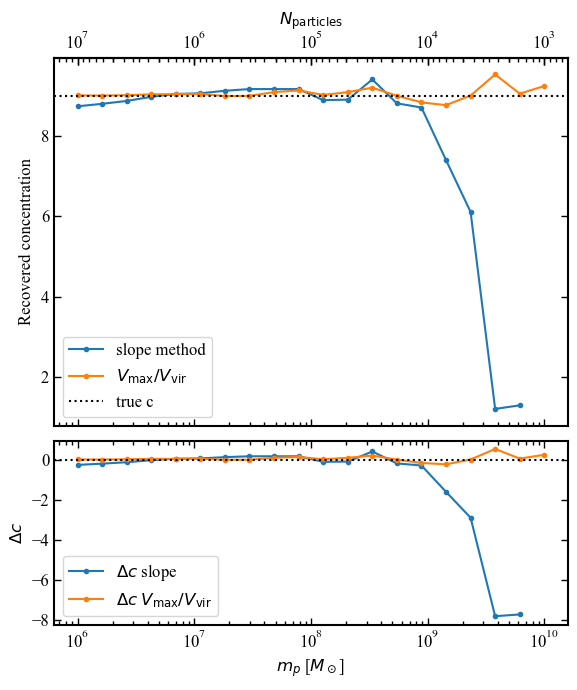

In [63]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(6,7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# --------------------------------------------------
# Top panel: recovered concentration
# --------------------------------------------------

ax = axes[0]

ax.plot(
    df["mp"],
    df["c_slope"],
    marker=".",
    label="slope method"
)

ax.plot(
    df["mp"],
    df["c_vmax"],
    marker=".",
    label="$V_{\\rm max}/V_{\\rm vir}$"
)

ax.axhline(
    ctrue,
    color="k",
    ls=":",
    label="true c"
)

ax.set_xscale("log")
ax.set_ylabel("Recovered concentration")

ax.legend()


# --------------------------------------------------
# Bottom panel: concentration error
# --------------------------------------------------

ax = axes[1]

ax.plot(
    df["mp"],
    df["c_slope"] - ctrue,
    marker=".",
    label="$\\Delta c$ slope"
)

ax.plot(
    df["mp"],
    df["c_vmax"] - ctrue,
    marker=".",
    label="$\\Delta c$ $V_{\\rm max}/V_{\\rm vir}$"
)

ax.axhline(
    0,
    color="k",
    ls=":"
)

ax.set_xscale("log")
ax.set_xlabel("$m_p$ [$M_\\odot$]")
ax.set_ylabel("$\\Delta c$")

ax.legend()


# --------------------------------------------------
# Secondary x-axis: number of particles
# --------------------------------------------------

def mp_to_N(mp):
    return host_halo_mass / mp


def N_to_mp(N):
    return host_halo_mass / N


secax = axes[0].secondary_xaxis(
    "top",
    functions=(mp_to_N, N_to_mp)
)

secax.set_xlabel("$N_{\\rm particles}$")


plt.tight_layout()
plt.show()

In [77]:
def Nseed_wrapper(Mvir, c_true, mp, Nseeds, seed_start):
    """
    Measure concentration over multiple random realizations.
    Returns the mean and scatter from different particle samples.
    """
    results = []

    for i in range(Nseeds):

        out = compare_concentration_methods(
            Mvir,
            c_true,
            mp,
            seed=seed_start + i
        )

        results.append(out)


    # convert to dataframe for easy statistics
    results = pd.DataFrame(results)

    return {
        "mp": mp,
        "c_true": c_true,

        "c_slope_mean": np.nanmean(results["c_slope"]),
        "c_slope_std": np.nanstd(results["c_slope"]),

        "c_vmax_mean": np.nanmean(results["c_vmax"]),
        "c_vmax_std": np.nanstd(results["c_vmax"]),

        "rs_slope_mean": np.nanmean(results["rs_slope"]),
        "Vmax_mean": np.nanmean(results["Vmax"])}

In [80]:
particle_masses = np.logspace(6, 9, 10)

host_halo_mass = 1e13
ctrue = 9

results = []

for mp in particle_masses:

    out = Nseed_wrapper(
        Mvir=host_halo_mass,
        c_true=ctrue,
        mp=mp,
        Nseeds=100,
        seed_start=0
    )

    results.append(out)


df = pd.DataFrame(results)

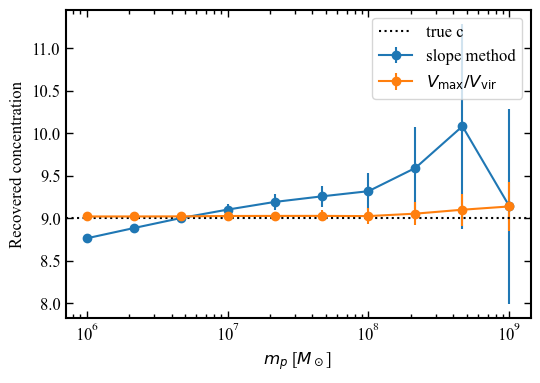

In [81]:
fig, ax = plt.subplots(figsize=(6,4))

ax.errorbar(
    df["mp"],
    df["c_slope_mean"],
    yerr=df["c_slope_std"],
    marker="o",
    label="slope method"
)

ax.errorbar(
    df["mp"],
    df["c_vmax_mean"],
    yerr=df["c_vmax_std"],
    marker="o",
    label="$V_{\\rm max}/V_{\\rm vir}$"
)

ax.axhline(
    ctrue,
    color="k",
    ls=":",
    label="true c"
)

ax.set_xscale("log")
ax.set_xlabel("$m_p$ [$M_\\odot$]")
ax.set_ylabel("Recovered concentration")

ax.legend()
plt.show()

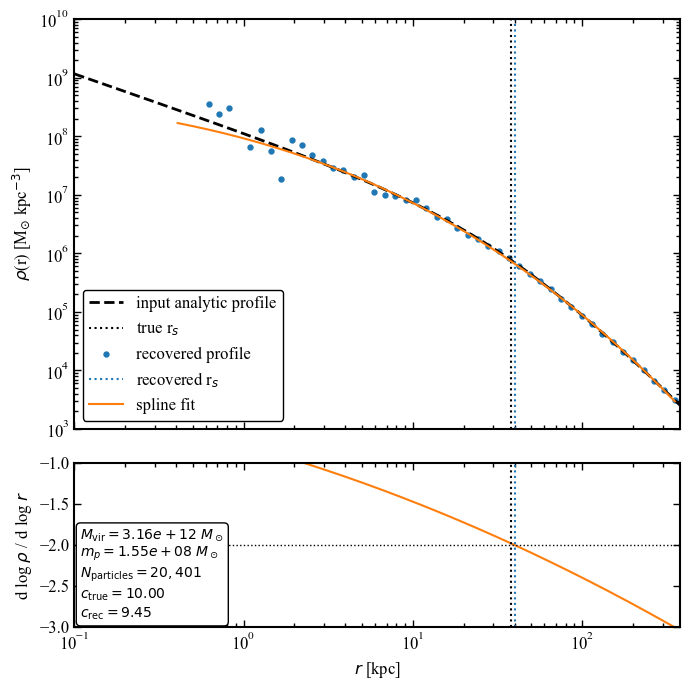

In [33]:
def measure_c(Mvir, c_true, mp, seed=42, plot=False):

    rng = np.random.default_rng(seed)

    profile = profiles.NFW(Mvir, c_true, cfg.Dvsample[0], cfg.zsample[0])
    rsmooth = np.logspace(-1, np.log10(profile.rh), 100)
    rvir = profile.rh

    rs_true = rvir / c_true
    N_particles = int(Mvir / mp)

    # --- Sample particles ---
    r = sample_nfw_radii(N_particles, rvir, c_true, rng)

    # --- Sample particles ---
    rad_bins = np.logspace(np.log10(1e-3*rvir), np.log10(rvir), 50)

    centers, rho, counts = measure_density_profile(r, mp, edges=rad_bins)
    rs_rec, spline = recover_rs_from_slope(centers, rho, counts=counts, min_counts=10, s=0.01*rad_bins.shape[0])
    c_rec = rvir / rs_rec  # take first root if recover_rs_from_slope found several

    if plot==True:

        fig, axes = plt.subplots(2, 1, figsize=(double_textwidth, double_textwidth), sharex=True,
                                    gridspec_kw={"height_ratios": [2.5, 1]})

        axes[0].plot(rsmooth, profile.rho(rsmooth),color="k", ls="--", lw=2, label="input analytic profile")
        axes[0].axvline(rs_true, color="k", ls=":", label="true r$_s$")

        axes[0].scatter(centers, rho, marker=".", s=50, label="recovered profile")
        axes[0].axvline(rs_rec, ls=":", label="recovered r$_s$")

        # --- spline fit, evaluated over the same range as the binned points ---
        logr_fine = np.linspace(np.log(centers.min()), np.log(centers.max()), 400)
        axes[0].plot(np.exp(logr_fine), np.exp(spline(logr_fine)), color="C1", lw=1.5,
                    label="spline fit")

        axes[0].set_ylabel("$\\rho$(r) [M$_{\\odot}$ kpc$^{-3}$]")
        axes[1].set_xlabel("$r$ [kpc]")

        axes[0].legend(facecolor="white", framealpha=1, edgecolor="k")

        axes[0].set_xscale("log")
        axes[0].set_yscale("log")

        # --- bottom panel: dlnrho/dlnr from the spline ---
        dspline = spline.derivative(1)

        axes[1].plot(np.exp(logr_fine), dspline(logr_fine), color="C1", lw=1.5)
        axes[1].axhline(-2, color="k", ls=":", lw=1)
        axes[1].axvline(rs_true, color="k", ls=":")
        axes[1].axvline(rs_rec, ls=":")
        axes[1].set_ylabel("d log $\\rho$ / d log $r$")

        axes[1].set_xlim(rsmooth.min(), rsmooth.max())

        info_text = (
            rf"$M_{{\rm vir}} = {Mvir:.2e}\ M_\odot$" "\n"
            rf"$m_p = {mp:.2e}\ M_\odot$" "\n"
            rf"$N_{{\rm particles}} = {N_particles:,}$" "\n"
            rf"$c_{{\rm true}} = {c_true:.2f}$" "\n"
            rf"$c_{{\rm rec}} = {c_rec:.2f}$"
        )

        axes[1].text(0.01, 0.06, info_text, transform=axes[1].transAxes, bbox=dict(boxstyle="round", facecolor="white", alpha=1))
        axes[1].set_ylim(-3, -1)
        axes[0].set_ylim(1e3,1e10)

        plt.tight_layout()
        plt.show()


    else:
        return c_rec

measure_c(Mvir=10**(12.5), c_true=10, mp=1.55e8, seed=15, plot=True)

In [10]:
def plummer_density(r, a):
    """
    Plummer density profile, normalized to total mass = 1.
    Multiply by M (total mass) to get physical density.

        rho(r) = (3 / 4*pi*a^3) * (1 + (r/a)^2)^(-5/2)

    r : radius (array or scalar)
    a : Plummer scale radius
    """
    return (3.0 / (4.0 * np.pi * a**3)) * (1.0 + (r / a) ** 2) ** (-2.5)

def sample_plummer_radii(N, a, seed):
    """
    Inverse-transform sampling of radii from a Plummer sphere of scale
    radius `a`, centered at the origin.

    CDF:  F(x) = x^3 / (1+x^2)^(3/2),  x = r/a
    Inverted analytically (no grid/interp needed, unlike NFW):
        x = sqrt(u^(2/3) / (1 - u^(2/3)))
    """

    rng = np.random.default_rng(seed)
    u = rng.random(N)
    u23 = u ** (2.0 / 3.0)
    x = np.sqrt(u23 / (1.0 - u23))
    return x * a

N = 6451 particles


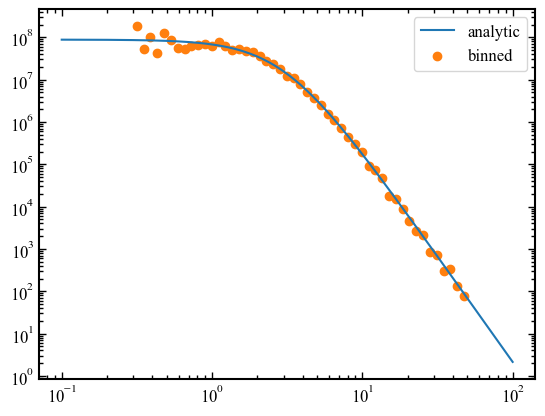

In [11]:
a = 3          # kpc
M_sub = 1e10    # Msun/h
mp = 1.55e6    # Msun/h

N = int(M_sub / mp)   # <- tie N to M_sub, not 1e12
print(f"N = {N} particles")

subrad = np.linspace(0.1, 100, 1000)
rho_sub = M_sub * plummer_density(subrad, a)

rad_bins = np.logspace(np.log10(1e-1 * a), np.log10(50), 50)

positions = sample_plummer_radii(N, a, seed=42)
centers, rho, counts = measure_density_profile(positions, mp, rad_bins)

plt.plot(subrad, rho_sub, label="analytic")
plt.scatter(centers, rho, c="C1", label="binned")
plt.yscale("log")
plt.xscale("log")
plt.legend()